In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ev = pd.read_csv("../data/raw/ev_sessions.csv")

load = pd.read_csv("../data/raw/scaled_largehotel_profile.csv")

Convert timestamps

In [3]:
ev["connection_timestamp"] = pd.to_datetime(
    ev["connection_timestamp"]
)

ev["full_timestamp"] = pd.to_datetime(
    ev["full_timestamp"]
)

ev["disconnection_timestamp"] = pd.to_datetime(
    ev["disconnection_timestamp"]
)

load["timestamp"] = pd.to_datetime(
    load["timestamp"]
)

Select the high-demand day. ~ Day 95 = High demand ~ We did already 

In [5]:
DAY = 95

ev_day = ev[ev["day"] == DAY].copy()

print("Sessions:", len(ev_day))
print("Energy:", ev_day["energy_kwh"].sum())
# ASAP charging: start charging immediately upon connection, and continue until full or disconnection

Sessions: 35
Energy: 509.0


Inspect the 35 vehicles

In [6]:
ev_day[
    [
        "connection_minute",
        "full_minute",
        "disconnection_minute",
        "energy_kwh"
    ]
].head(10)

,connection_minute,full_minute,disconnection_minute,energy_kwh
2253,510,895,1045,23.0
2254,665,1032,1146,26.0
2255,805,945,987,0.0
2256,510,641,916,14.0
2257,517,832,1093,34.0
2258,398,805,887,29.0
2259,519,844,942,33.0
2260,597,736,950,16.0
2261,539,1009,1119,14.0
2262,517,611,729,8.0


510 min  = 08:30 arrival
895 min  = 14:55 fully charged
1045 min = 17:25 departure ~ 2.5 hours of flexibility 

No charging demand ~ energy_kwh = 0 ~ as they are not a part of the optimization problem.

In [8]:
(ev_day["energy_kwh"] == 0).sum()

np.int64(1)

Now let's build the first real charging profile

Assumptions:
7 kW charger ||
Charging starts immediately when vehicle arrives ||
Charging stops when required energy is delivered

In [ ]:
# Fixed charging power of every charger [kW]
charger_power = 7.0

# Simulation resolution:
# 1 value per hour
dt = 1.0

# Hours of the day:
# [0,1,2,...,23]
hours = np.arange(24)

# This vector will contain the total EV charging power
# requested in every hour of the day
baseline_load = np.zeros(24)

# Loop through every EV charging session
for _, car in ev_day.iterrows():

    # Energy that still needs to be delivered
    energy_remaining = car["energy_kwh"]

    # Skip EVs with zero charging requirement
    if energy_remaining <= 0:
        continue

    # Arrival time [minutes after midnight]
    start_min = int(car["connection_minute"])

    # Time when charging finishes [minutes after midnight]
    end_min = int(car["full_minute"])

    # Check every hour of the day
    for h in range(24):

        # Hour boundaries
        hour_start = h * 60
        hour_end = (h + 1) * 60

        # Calculate how many minutes of this hour
        # overlap with the charging interval
        overlap_min = max(
            0,
            min(end_min, hour_end)
            - max(start_min, hour_start)
        )

        # If overlap exists
        if overlap_min > 0:

            # Energy delivered during this overlap
            energy_this_hour = (
                charger_power
                * overlap_min / 60
            )

            # Never deliver more energy than required
            energy_this_hour = min(
                energy_this_hour,
                energy_remaining
            )

            # Convert energy into average power
            # during this 1-hour slot
            baseline_load[h] += (
                energy_this_hour / dt
            )

            # Update remaining energy
            energy_remaining -= energy_this_hour

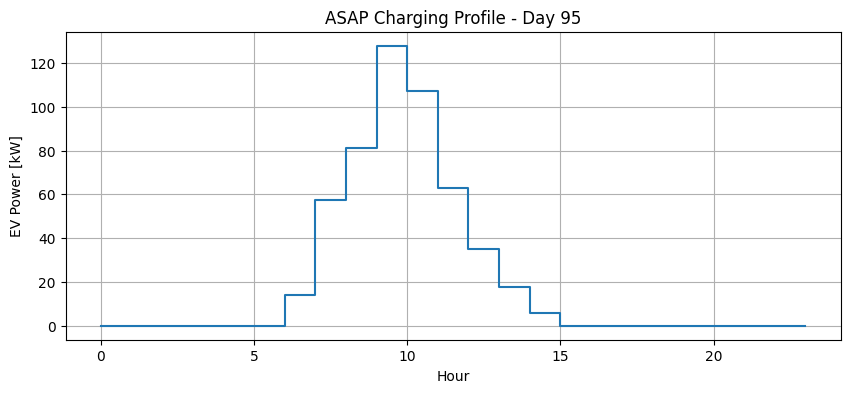

In [17]:
plt.figure(figsize=(10,4))
plt.step(hours, baseline_load, where="post")
plt.grid()
plt.xlabel("Hour")
plt.ylabel("EV Power [kW]")
plt.title("ASAP Charging Profile - Day 95")
plt.show()

Actual energy represented by the profile ~ the actual baseline load.

In [18]:
baseline_load.sum()

np.float64(509.00000000000006)